# Langgraph - AI chat-bot

## Import necessary libraries and create necessary objects

In [1]:
# import the necessary libraries
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from dotenv import load_dotenv
from langchain_community.utilities import SQLDatabase

In [2]:
# load environment variables
_ = load_dotenv()

In [3]:
# create llm
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
memory = MemorySaver()
parser = StrOutputParser()
embeddings = OpenAIEmbeddings()

In [4]:
# create database object
olist = SQLDatabase.from_uri('sqlite:///olist.db')

In [5]:
# create table info
olist_info = """
orders(order_id, customer_id, order_status, order_purchase_timestamp)
customers(customer_id, customer_zip_code_prefix, customer_city, customer_state)
items(order_id, product_id, seller_id, price, freight_value)
products(product_id, product_category_name, product_weight_g)
sellers(seller_id, seller_zip_code_prefix, seller_city, seller_state)
payments(order_id, payment_type, payment_installments, payment_value)
reviews(order_id, review_score, review_comment_message)
"""

In [6]:
# create a vector store
vectorstores = FAISS.load_local("faiss_db", embeddings, allow_dangerous_deserialization=True)

## prompt part

### RAG Prompt

In [7]:
# create a prompt template
rag_prompt = ChatPromptTemplate.from_messages([
    (
    'system',
    """
        You are a AI-CHATBOT. 
        You have our company's custmer review. 
        You know all data info in our company like customer review, customer order.
        When customer ask a question, you will know the question and base on faiss_result, you will out put a clear, correct answer.
        If sql_result exists, you should combine sql_result and faiss_result and question to get a better answer.

        NOTICE:
            THE ANSWER MUST FOLLOW BY faiss_result AND question AND sql_result(IF EXISTS), WHEN DO NOT GET ENOUGH INFORMATION, PLEASE OUT A APOLOGIZE TO SAY YOU DO NOT PLEASE TRY ANOTHER PROOBELM.
            BEFORE OUTPUT, YOU SHOULD TRANSALTE THE SUMMARY TO BE ENGLISH
    """
    ),
    (
    'user',
    """
        question:{question}
        faiss_result:{faiss_result}
        sql_result:{sql_result} (if exists)
    """
    )
])

### SQL Prompt

In [8]:
sql_query_prompt = ChatPromptTemplate.from_messages([
    ('system',
        """
        - orders → customers : orders.customer_id = customers.customer_id
        - orders → items : orders.order_id = items.order_id
        - orders → payment : orders.order_id = payment.order_id
        - orders → review : orders.order_id = review.order_id
        - items → products : items.product_id = products.product_id
        - items → sellers : items.seller_id = sellers.seller_id
        - customers → geolocation : customers.customer_zip_code_prefix = geolocation.geolocation_zip_code_prefix
        - sellers → geolocation : sellers.seller_zip_code_prefix = geolocation.geolocation_zip_code_prefix
        This is the relationship between the tables.
        please based on question and table info, to write the correct SQL query.
        
        CRITICAL OVERRIDE RULE:
         - WHEN ABOUT RECOMMENDATION, MUST USE DENSE_RANK OR OTHER WINDOW FUNCTION TO SOLVE THE PROBLEM
         - USE WINDOW FUNCTIONS LIKE DENSE_RANK() FOR RECOMMENDATIONS. EXAMPLE
             WITH rk_data AS(
                SELECT a, DENSE_RANK() OVER (PARITTION BY category ORDER BY PRICE DESC) rk FROM category_table
            ) 
            SELECT a FROM rk_data WHERE rk <= 3
            IN THIS SITUATION, MUST PARTITION BY category TO RANK. EXAMPLE
            SELECT DISTINCT a FROM rk_data WHERE rk<=3
            IF HAVING BUDGET LIMIT, MUST USE WHERE TO FILTER PRICE BEFORE RANK. EXAMPLE
             WITH rk_data AS(
                SELECT a, DENSE_RANK() OVER (PARITTION BY category ORDER BY PRICE DESC) rk FROM category_table WHERE price <= 50
            ) 
            RECOMMENDATION NOTICE: WHATEVER USING WHICH FEATRUE TO RANK, SHOULD RANK PRICE TOO. EXAMPLE
               WITH rk_data AS(
                SELECT a, DENSE_RANK() OVER (PARITTION BY category ORDER BY SCORE DESC, PRICE DESC) rk FROM category_table WHERE price <= 50
            ) 
            WHEN FILTERING ON WINDOW FUNCTION RESULT, ALWAYS WRAP IN ANOTHER CTE:
                WITH base AS (...),
                ranked AS (SELECT *, DENSE_RANK() OVER (...) AS rk FROM base)
                SELECT * FROM ranked WHERE rk <= 3;

            
        NOTICE: 
            - ONLY WRITE THE DQL, DO NOT WRITE DML OR DDL
            - ONLY RETURN THE SQL QUERY WITHOUT MANY MARKDOWNS AND ORIGINAL QUESTION, ONLY PURE SQL QUERY
            - FOR RECOMMENDATION PROBLEM, USE DENSE_RANK() OR OTHER WINDOW FUNCTION WITH WHERE rk<=3, DO NOT ADD LIMIT
            - FRO OTHER QUERY WITHOUT WINDOW FUNCTION, USE LIMIT 10
            - NEVER RUTURN SOME MARKDOWNS
            - JUST OUTPUT NESSERARY OUTPUT, WHICH MINIMUM CAN ANSWER THE QUESTION
            - FOR RECOMMENDATION PROBLEM, MUST USE WINDOW FUNCTION LIKE DENSE_RANK(), RANK(), ROW_NUMBER() TO GET THE RANK NUMBER. IF THE QUESTION DO NOT INCLUDE HOW MANY VALUE TO OUTPUT, DEFAULT rk<=3, IF QUESTION SAY TOPN, MUST rk<=N. 
            - OUTPUT MUST DISTINCT, DO NOT OUTPUT SAME
            - PRODUCT CATEGROY IS NOT NULL WHEN QUERY, USING WHERE TO FILTER THE NULL VALUE
            - WHEN ALIGN FOR THE SUB-QUERY OR ECT, AVIDO TO USE THE SEPCIAL NAME IN SQL LIKE RANK, DEN_RANK, ORDER OR OTHERS
            - FOR EACH FEATURE, SHOULD OUTPUT WITH TABLE ALIGN LIKE PRICE SHOULD OBVIOUSLY WRITE FOR P.PRICE, P.PRODUCT_ID AND LIKE THIS.
        """
    ),
    (
    'user',
    """
        question:{question}
        table_info:{table_info}
    """
    )
])

In [9]:
# create sql summary prompt
sql_summary_prompt = ChatPromptTemplate.from_template(
    """
        You are a customer service chatbot for Olist, a Brazilian e-commerce platform.
        You can help customers with questions about orders, products, reviews, sellers and deliveries.
        Based on the query result, give a friendly and professional answer.
        If the query_result is empty, tell the customer you couldn't find relevant information. 
        
        question:{question}
        query_result:{query_result}
        table_info:{table_info}
    """
)

In [10]:
sql_error_prompt = ChatPromptTemplate.from_messages([
    (
    'system',
    """
        You are a customer service chatbot for Olist, a Brazilian e-commerce platform.
        You can help customers with questions about orders, products, reviews, sellers and deliveries.
        You are given a question and a sql error_msg.
        That you can not answer these question in these times.
        So please return a clear, correct human language answer to tell the customer that these question is not in the scope of this bot.
        The answer do not include any SQL query and technical terms.
        You can recommend the customer to contact the customer service.
    """
    ),
    (
    'user',
    """
        question:{question}
        error_result:{error_result}
    """
    )
])

### Usual LLM Prompt

In [11]:
llm_prompt = ChatPromptTemplate.from_messages([
    (
    'system',
    """
        You are a AI CHATBOT
        You have our company data info
        Only the problem can not be search in our data you will be used
        Base on the question and olist info
    """
    ),
    (
    'user',
    """
        STEP:
            1. base on customer question, answer the question if you can.
            2. if the question is not about our company product, after answer, tell customer to try our business problem
            3. also can recommend to Live Support if the question is abstract and hard to understand

        question:{question}
        table_info:{table_info}
            
    """
    )
])

### Router prompt

In [12]:
route_prompt = ChatPromptTemplate.from_messages([
    (
    'system',
    """
        This prompt to define the question is go to SQL path, RAG path, HYBRID path or LLM path.
        CRITICAL OVERRIDE RULE:
            IF QUESTION INCLUDES BUDGET/PRICE CONSTRAINT:
              - IF ALSO mentions reviews/recommendations/quality → return "hybrid"
              - IF ONLY asks for data/statistics → return "sql"
              NEVER return "rag" when budget is mentioned.
            THIS RULE OVERRIDES ALL OTHER RULES.
        
        1. return rag:
            When the question is about: 
                customer feeling, 
                product review
                problem for product like delivery delay problem, quality problem
                When question is about delivery, like day, feeling

        2. return sql:
            When the question is about:
                Structure problem like top10 selling,
                Math problem for product like total seeling, how much

        3. return hybrid:
            WHen the question is about:
                Some quesiton is both about product info and customer review
                for example: I have 100 and I wanna choose a gift for my friend.
                Llke the example, need both SQL process and RAG process to get the result

        4. return llm
            Not about the product like hello, hi, how are you some problem without a special information

        The output only return sql,rag or llm in lowercase, don't return any other answer
    """
    ),
    (
    'user',
    """
        question: {question}
    """
    )
])

## LLM chain

In [13]:
# create sql query chain
sql_query_chain = sql_query_prompt | llm | parser
# create sql summary chain
sql_summary_chain = sql_summary_prompt | llm | parser
# create sql error chain
sql_error_chain = sql_error_prompt | llm | parser
# create rag chain
rag_chain = rag_prompt | llm | parser
# create llm chain
llm_chain = llm_prompt | llm | parser
# create route chain
route_chain = route_prompt | llm | parser

## Create State

In [14]:
class ChatBotState(MessagesState):
    router: str | None = None
    sql_query: str | None = None
    query_result: str | None = None
    error_result: str | None = None
    error_count: int = 0



## Function/Node creation

### Function part

#### Router Node

In [15]:
def router_node(state: ChatBotState):
    question = state["messages"][-1].content
    router = route_chain.invoke({"question": question})
    return {"router": router}

#### LLM Node

In [16]:
def llm_node(state: ChatBotState):
    table_info = olist_info
    question = state["messages"][-1].content
    answer = llm_chain.invoke({"question": question, "table_info": table_info})
    return {'messages': [AIMessage(content=answer)], 'router':None}

#### RAG Node

In [17]:
def rag_node(state: ChatBotState):
    question = state["messages"][-1].content
    faiss_result = [i.page_content for i in vectorstores.similarity_search(question, k = 3)]
    answer = rag_chain.invoke({"question": question, "faiss_result": faiss_result, "sql_result": state.get("query_result",'')})
    return {
        'messages': [AIMessage(content=answer)],
        'router': None,
        'sql_query': None,
        'query_result': None,
        'error_result': None,
        'error_count': 0
        }

#### SQL Node

In [18]:
def sql_query_node(state: ChatBotState):
    question = state["messages"][-1].content
    table_info = olist_info
    sql_query = sql_query_chain.invoke({
        "question": question,
        "table_info": table_info,
        "error_result": state.get("error_result",''),
        "sql_result": state.get("sql_result",'')
    })
    return {'sql_query': sql_query}

In [19]:
def sql_result_node(state: ChatBotState):
    try:
        query_result = olist.run(state["sql_query"])
        return {'query_result': query_result, 'error_result': None}
    except Exception as e:
        error_count = state.get("error_count") + 1
        return {'error_result': str(e), 'error_count': error_count}

In [ ]:
def sql_summary_node(state: ChatBotState):
    question = state["messages"][-1].content
    table_info = olist_info
    query_result = state["query_result"]
    answer = sql_summary_chain.invoke({"question": question, "query_result": query_result, "table_info": table_info})
    return {'messages': [AIMessage(content=answer)],
            'router': None,
            'sql_query': None,
            'query_result': None,
            'error_result': None,
            'error_count': 0
            }
    

In [ ]:
def sql_error_node(state: ChatBotState):
    question = state["messages"][-1].content
    error_result = state["error_result"]
    answer = sql_error_chain.invoke({"question": question, "error_result": error_result})
    return {
        'messages': [AIMessage(content=answer)],
        'router': None,
        'sql_query': None,
        'query_result': None,
        'error_result': None,
        'error_count': 0
        }
    


### function part

In [22]:
def router_function(state: ChatBotState):
    if state.get("router") == "sql" or state.get("router") == "hybrid":
        return 'sql_query_node'
    elif state.get("router") == "rag":
        return 'rag_node'
    elif state.get("router") == "llm":
        return 'llm_node'

In [ ]:
def router_check_function(state: ChatBotState):
    if state.get('error_count'):
        if state.get('error_count') >= 3:
            return 'sql_error_node'
        else:
            return 'sql_query_node'
    else:
        if state.get('router') == 'sql':
            return 'sql_summary_node'
        else:
            return 'rag_node'

## Graph

In [24]:
# create graph
graph = StateGraph(ChatBotState)

In [25]:
# add nodes
graph.add_node("router_node", router_node)
graph.add_node("llm_node", llm_node)
graph.add_node("rag_node", rag_node)
graph.add_node("sql_query_node", sql_query_node)
graph.add_node("sql_result_node", sql_result_node)
graph.add_node("sql_summary_node", sql_summary_node)
graph.add_node("sql_error_node", sql_error_node)

In [26]:
# set entry point
graph.set_entry_point("router_node")

In [27]:
graph.add_conditional_edges(
    "router_node",
    router_function,
    {
        "sql_query_node": "sql_query_node",
        "rag_node": "rag_node",
        "llm_node": "llm_node"
    }
)
graph.add_edge('llm_node', END)
graph.add_edge('rag_node', END)
graph.add_edge('sql_query_node', 'sql_result_node')
graph.add_conditional_edges(
    'sql_result_node',
    router_check_function,
    {
        'sql_error_node': 'sql_error_node',
        'sql_summary_node': 'sql_summary_node',
        'sql_query_node': 'sql_query_node',
        'rag_node': 'rag_node'
    }
)
graph.add_edge('sql_error_node', END)
graph.add_edge('sql_summary_node', END)

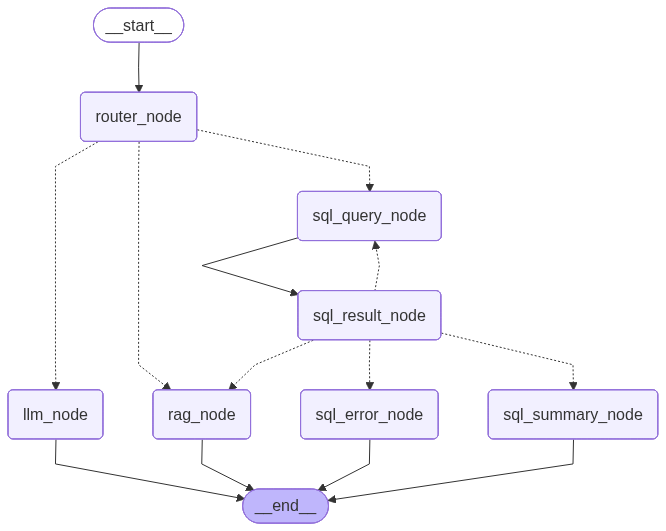

In [28]:
graph.compile(checkpointer=memory)

In [29]:
app = graph.compile(checkpointer=memory)

In [30]:
config = {"configurable": {"thread_id": "1"}}

In [31]:
app.invoke({"messages": [HumanMessage(content="How many orders are there?")]}, config=config)

{'messages': [HumanMessage(content='How many orders are there?', additional_kwargs={}, response_metadata={}, id='ff101da3-1fb2-4352-9d3a-50e30d9b7811'),
  AIMessage(content='Hello! Currently, there are a total of 99,441 orders on our platform. If you have any more questions or need assistance with something else, feel free to ask!', additional_kwargs={}, response_metadata={}, id='2b1cdf5c-b624-4697-8b57-5b7aa7b396af', tool_calls=[], invalid_tool_calls=[])],
 'router': 'sql',
 'sql_query': 'SELECT COUNT(*) AS total_orders FROM orders;',
 'query_result': '[(99441,)]',
 'error_result': None}

In [32]:
app.invoke({"messages": [HumanMessage(content="What do customers think about delivery?")]}, config=config)

{'messages': [HumanMessage(content='How many orders are there?', additional_kwargs={}, response_metadata={}, id='ff101da3-1fb2-4352-9d3a-50e30d9b7811'),
  AIMessage(content='Hello! Currently, there are a total of 99,441 orders on our platform. If you have any more questions or need assistance with something else, feel free to ask!', additional_kwargs={}, response_metadata={}, id='2b1cdf5c-b624-4697-8b57-5b7aa7b396af', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What do customers think about delivery?', additional_kwargs={}, response_metadata={}, id='b2d8adb4-2762-4293-b950-ba0ba3e005be'),
  AIMessage(content='Customers generally have a positive view of the delivery service. They appreciate how it makes life easier, although some suggest that there should be more agility in the delivery process. One customer expressed satisfaction with the delivery, service, and product, while another emphasized the importance of timely delivery as a key factor in their satisfaction.\

In [33]:
app.invoke({"messages": [HumanMessage(content="What are the top products and what do customers say about them?")]}, config=config)

{'messages': [HumanMessage(content='How many orders are there?', additional_kwargs={}, response_metadata={}, id='ff101da3-1fb2-4352-9d3a-50e30d9b7811'),
  AIMessage(content='Hello! Currently, there are a total of 99,441 orders on our platform. If you have any more questions or need assistance with something else, feel free to ask!', additional_kwargs={}, response_metadata={}, id='2b1cdf5c-b624-4697-8b57-5b7aa7b396af', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What do customers think about delivery?', additional_kwargs={}, response_metadata={}, id='b2d8adb4-2762-4293-b950-ba0ba3e005be'),
  AIMessage(content='Customers generally have a positive view of the delivery service. They appreciate how it makes life easier, although some suggest that there should be more agility in the delivery process. One customer expressed satisfaction with the delivery, service, and product, while another emphasized the importance of timely delivery as a key factor in their satisfaction.\

In [34]:
app.invoke({"messages": [HumanMessage(content="What can you help me with?")]}, config=config)

{'messages': [HumanMessage(content='How many orders are there?', additional_kwargs={}, response_metadata={}, id='ff101da3-1fb2-4352-9d3a-50e30d9b7811'),
  AIMessage(content='Hello! Currently, there are a total of 99,441 orders on our platform. If you have any more questions or need assistance with something else, feel free to ask!', additional_kwargs={}, response_metadata={}, id='2b1cdf5c-b624-4697-8b57-5b7aa7b396af', tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='What do customers think about delivery?', additional_kwargs={}, response_metadata={}, id='b2d8adb4-2762-4293-b950-ba0ba3e005be'),
  AIMessage(content='Customers generally have a positive view of the delivery service. They appreciate how it makes life easier, although some suggest that there should be more agility in the delivery process. One customer expressed satisfaction with the delivery, service, and product, while another emphasized the importance of timely delivery as a key factor in their satisfaction.\